# Healthcare Service Distribution in Indonesia

## Project Background
This project analyzes the distribution of healthcare services across Indonesian provinces using hospital data. The goal is to understand disparities in healthcare accessibility and identify regions that may require improved healthcare infrastructure.

In [1]:
#install tools
!pip install geopandas folium mapclassify openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import os

os.listdir()

['.config', 'archive (2).zip', 'sample_data']

In [25]:
#Load dataset
import pandas as pd


!head -n 20 'Hospital_Indonesia_datasets.csv'

id;nama;propinsi;kab;alamat;jenis;kelas;status_blu;kepemilikan;total_tempat_tidur;total_layanan;total_tenaga_kerja
1110053;RS Arun Lhokseumawe;Aceh;Kota Lhokseumawe;Jl. Plaju Komplek Perumahan PT Arun Batuphat Timur, Kec. Muara Satu;Rumah Sakit Umum;C;Non BLU/BLUD;SWASTA/LAINNYA;218;36;328
1106014;RS Umum Fandika;Aceh;Aceh Tengah;Jl. Terminal Simpang Wariji Blangkolak 1 Kec. Bebesen;Rumah Sakit Umum;D;Non BLU/BLUD;SWASTA/LAINNYA;45;15;45
1171110;RS Umum Daerah Meuraxa;Aceh;Kota Banda Aceh;Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan Banda Raya;Rumah Sakit Umum;B;BLUD;Pemkot;310;77;487
1171163;RS Gigi Mulut Universitas Syiah Kuala;Aceh;Kota Banda Aceh;Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh Kel. Punge Jurong;Rumah Sakit Khusus Gigi dan Mulut;B;BLU;Kementerian Lain;11;24;0
1102027;RS Umum Daerah Kota Subulussalam;Aceh;Kota Subulussalam;  Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec. Simpang Kiri Kota Subulussalam Aceh 24782;Rumah Sakit Umum;C;BLUD;Pemkot;189;34;537
1106013;RS Umu

In [16]:
import os
os.listdir()

['.config',
 'archive (2).zip',
 'Hospital_Indonesia_datasets.csv',
 'sample_data']

In [21]:
import pandas as pd

df = pd.read_csv('Hospital_Indonesia_datasets.csv', sep=';')

In [22]:
df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) K...,Rumah Sakit Umum,C,BLUD,Pemkot,189,34,537


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  3155 non-null   int64 
 1   nama                3155 non-null   object
 2   propinsi            3155 non-null   object
 3   kab                 3155 non-null   object
 4   alamat              3155 non-null   object
 5   jenis               3155 non-null   object
 6   kelas               3155 non-null   object
 7   status_blu          3155 non-null   object
 8   kepemilikan         3155 non-null   object
 9   total_tempat_tidur  3155 non-null   int64 
 10  total_layanan       3155 non-null   int64 
 11  total_tenaga_kerja  3155 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 295.9+ KB


In [24]:
df.columns

Index(['id', 'nama', 'propinsi', 'kab', 'alamat', 'jenis', 'kelas',
       'status_blu', 'kepemilikan', 'total_tempat_tidur', 'total_layanan',
       'total_tenaga_kerja'],
      dtype='object')

In [26]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [27]:
df.columns

Index(['id', 'nama', 'propinsi', 'kab', 'alamat', 'jenis', 'kelas',
       'status_blu', 'kepemilikan', 'total_tempat_tidur', 'total_layanan',
       'total_tenaga_kerja'],
      dtype='object')

In [29]:
rs_per_province = (
    df.groupby("propinsi")
    .size()
    .reset_index(name="jumlah_rumah_sakit")
    .sort_values("jumlah_rumah_sakit", ascending=False)
)

rs_per_province.head(10)

,propinsi,jumlah_rumah_sakit
9,Jawa Timur,432
7,Jawa Barat,421
8,Jawa Tengah,355
36,Sumatera Utara,202
4,DKI Jakarta,188
2,Banten,129
30,Sulawesi Selatan,123
35,Sumatera Selatan,87
28,Riau,81
17,Lampung,80


In [30]:
print("Jumlah data rumah sakit:", len(df))

Jumlah data rumah sakit: 3155


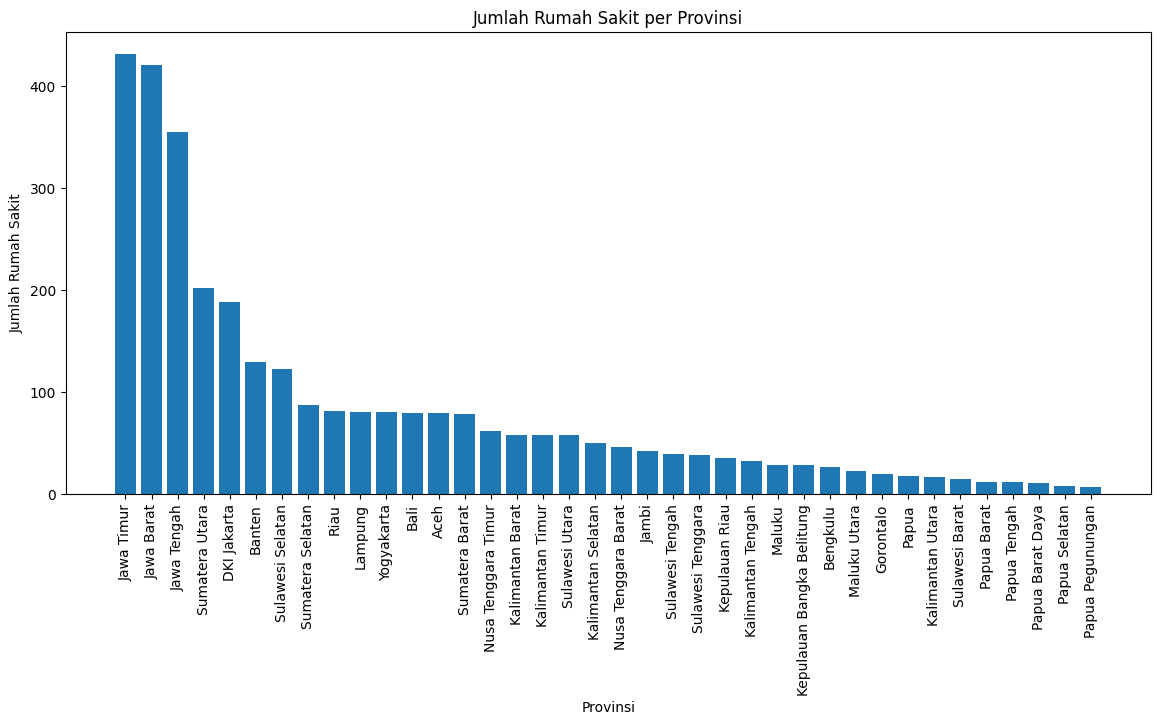

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    rs_per_province["propinsi"],
    rs_per_province["jumlah_rumah_sakit"]
)

plt.xticks(rotation=90)
plt.title("Jumlah Rumah Sakit per Provinsi")
plt.xlabel("Provinsi")
plt.ylabel("Jumlah Rumah Sakit")

plt.show()

In [35]:
rs_per_city = (
    df.groupby(["propinsi","kab"])
    .size()
    .reset_index(name="jumlah_rumah_sakit")
    .sort_values("jumlah_rumah_sakit", ascending=False)
)

rs_per_city.head(20)

,propinsi,kab,jumlah_rumah_sakit
151,Jawa Timur,Kota Surabaya,64
481,Sumatera Utara,Kota Medan,63
74,Jawa Barat,Bekasi,54
376,Sulawesi Selatan,Kota Makassar,52
53,DKI Jakarta,Kota Jakarta Selatan,50
84,Jawa Barat,Kota Bekasi,48
54,DKI Jakarta,Kota Jakarta Timur,44
82,Jawa Barat,Kota Bandung,42
52,DKI Jakarta,Kota Jakarta Pusat,37
116,Jawa Tengah,Kota Semarang,36


/tmp/ipykernel_231/456611303.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top20["wilayah"] = top20["kab"] + " - " + top20["propinsi"]


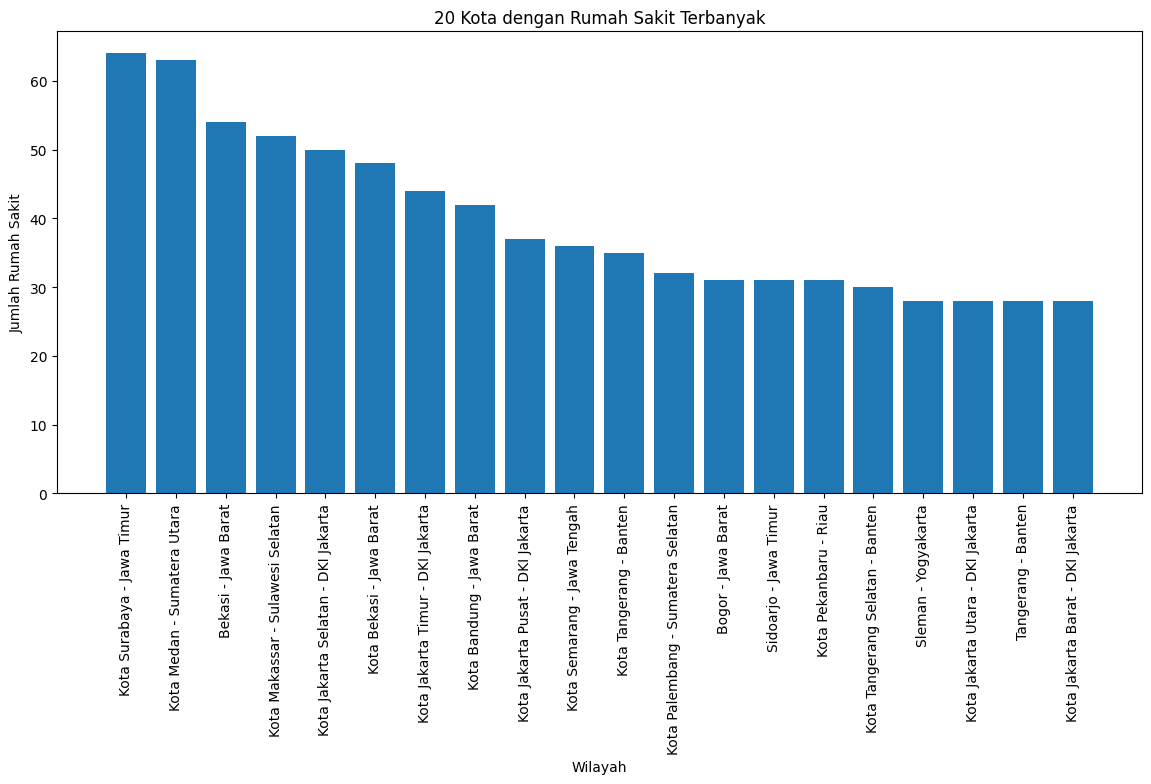

In [37]:
top20 = rs_per_city.head(20)

top20["wilayah"] = top20["kab"] + " - " + top20["propinsi"]

plt.figure(figsize=(14,6))

plt.bar(top20["wilayah"], top20["jumlah_rumah_sakit"])

plt.xticks(rotation=90)
plt.title("20 Kota dengan Rumah Sakit Terbanyak")
plt.xlabel("Wilayah")
plt.ylabel("Jumlah Rumah Sakit")

plt.show()

In [38]:
df.columns

Index(['id', 'nama', 'propinsi', 'kab', 'alamat', 'jenis', 'kelas',
       'status_blu', 'kepemilikan', 'total_tempat_tidur', 'total_layanan',
       'total_tenaga_kerja'],
      dtype='object')

In [39]:
rs_per_provinsi = (
    df.groupby("propinsi")
    .size()
    .reset_index(name="jumlah_rumah_sakit")
    .sort_values("jumlah_rumah_sakit", ascending=False)
)

rs_per_provinsi.head(10)

,propinsi,jumlah_rumah_sakit
9,Jawa Timur,432
7,Jawa Barat,421
8,Jawa Tengah,355
36,Sumatera Utara,202
4,DKI Jakarta,188
2,Banten,129
30,Sulawesi Selatan,123
35,Sumatera Selatan,87
28,Riau,81
17,Lampung,80


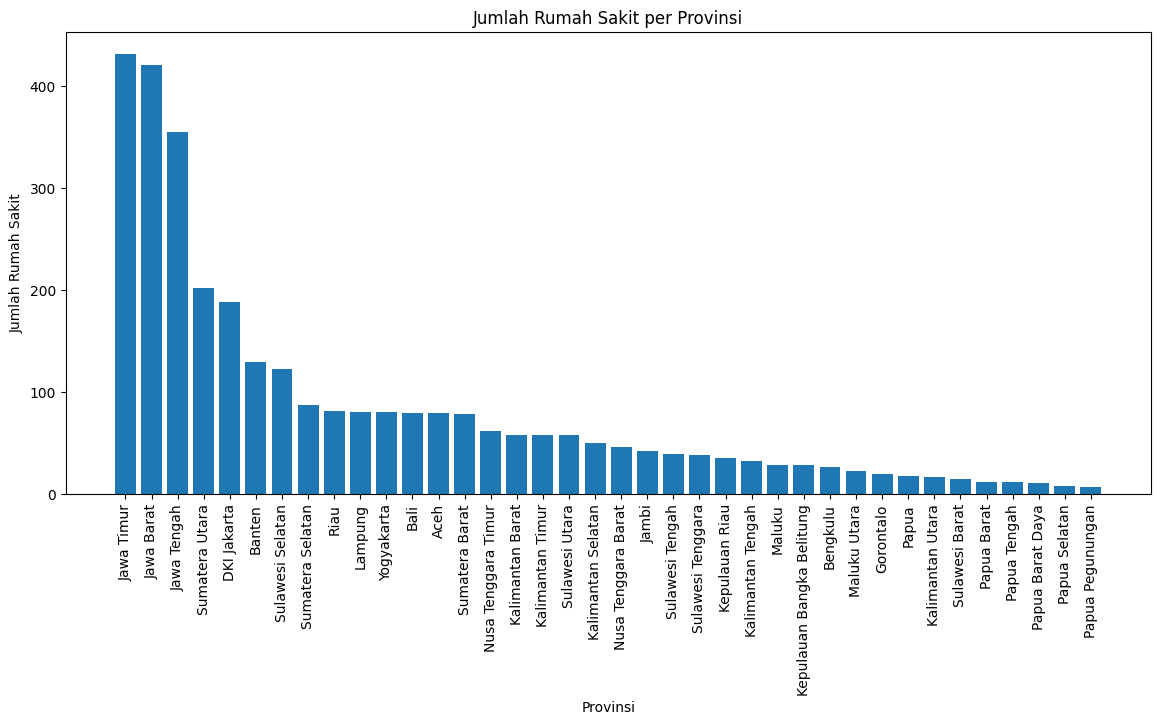

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    rs_per_provinsi["propinsi"],
    rs_per_provinsi["jumlah_rumah_sakit"]
)

plt.xticks(rotation=90)
plt.title("Jumlah Rumah Sakit per Provinsi")
plt.xlabel("Provinsi")
plt.ylabel("Jumlah Rumah Sakit")

plt.show()

In [41]:
df["kepemilikan"].value_counts()

,count
kepemilikan,
SWASTA/LAINNYA,869
Pemkab,648
Perusahaan,514
Organisasi Sosial,303
Pemprop,148
Pemkot,120
Organisasi Islam,119
TNI AD,77
Perorangan,73


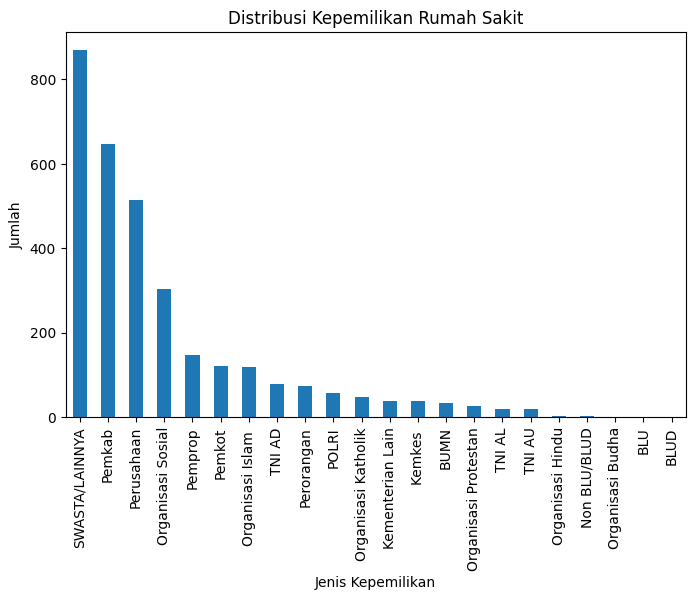

In [42]:
df["kepemilikan"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribusi Kepemilikan Rumah Sakit")
plt.xlabel("Jenis Kepemilikan")
plt.ylabel("Jumlah")
plt.show()

In [43]:
df["kelas"].value_counts()

,count
kelas,
C,1710
D,854
B,443
A,77
D PRATAMA,64
Belum Ditetapkan,3
Rumah Sakit Umum,3
Rumah Sakit Khusus Jiwa,1


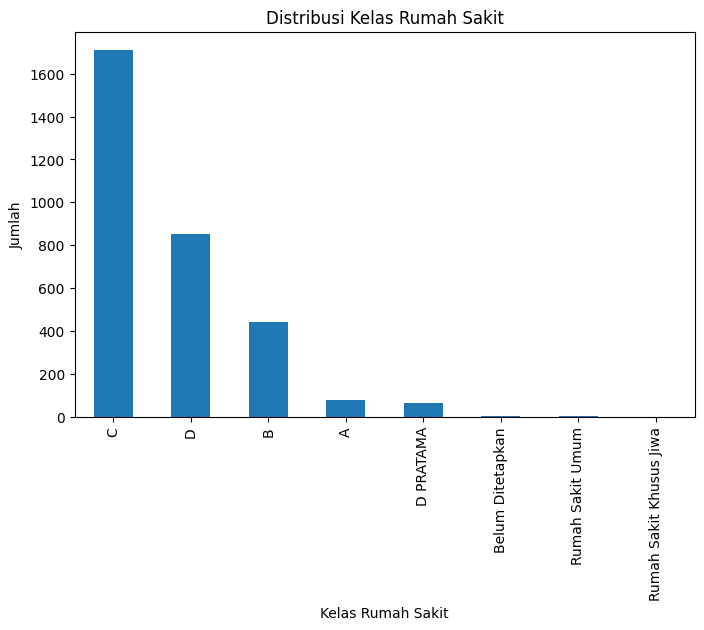

In [44]:
df["kelas"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribusi Kelas Rumah Sakit")
plt.xlabel("Kelas Rumah Sakit")
plt.ylabel("Jumlah")
plt.show()

In [45]:
df["total_tempat_tidur"].describe()

,total_tempat_tidur
count,3155.000000
mean,135.433914
std,550.960235
min,0.000000
25%,54.000000
50%,102.000000
75%,155.000000
max,30343.000000


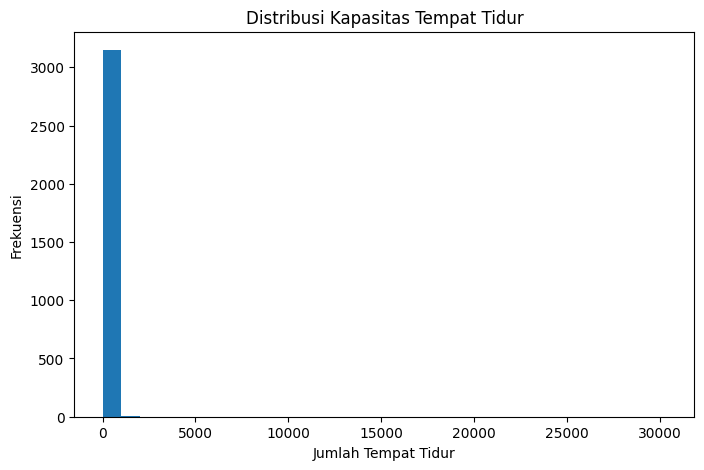

In [46]:
plt.figure(figsize=(8,5))

plt.hist(df["total_tempat_tidur"].dropna(), bins=30)

plt.title("Distribusi Kapasitas Tempat Tidur")
plt.xlabel("Jumlah Tempat Tidur")
plt.ylabel("Frekuensi")

plt.show()

In [47]:
df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  3155 non-null   int64 
 1   nama                3155 non-null   object
 2   propinsi            3155 non-null   object
 3   kab                 3155 non-null   object
 4   alamat              3155 non-null   object
 5   jenis               3155 non-null   object
 6   kelas               3155 non-null   object
 7   status_blu          3155 non-null   object
 8   kepemilikan         3155 non-null   object
 9   total_tempat_tidur  3155 non-null   int64 
 10  total_layanan       3155 non-null   int64 
 11  total_tenaga_kerja  3155 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 295.9+ KB


Index(['id', 'nama', 'propinsi', 'kab', 'alamat', 'jenis', 'kelas',
       'status_blu', 'kepemilikan', 'total_tempat_tidur', 'total_layanan',
       'total_tenaga_kerja'],
      dtype='object')

In [48]:
df.groupby("propinsi")["total_tempat_tidur"].sum()

,total_tempat_tidur
propinsi,
Aceh,11030
Bali,9203
Banten,15846
Bengkulu,2735
DKI Jakarta,30357
Gorontalo,2400
Jambi,4585
Jawa Barat,59802
Jawa Tengah,77753


In [49]:
df.groupby("propinsi")["total_tenaga_kerja"].sum()

,total_tenaga_kerja
propinsi,
Aceh,24643
Bali,22833
Banten,29083
Bengkulu,6997
DKI Jakarta,82785
Gorontalo,5391
Jambi,9867
Jawa Barat,113887
Jawa Tengah,102862


In [50]:
df.sort_values("total_tempat_tidur", ascending=False).head(10)

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
1403,3310015,RS Umum Pusat Dr. Soeradji Tirtonegoro,Jawa Tengah,Klaten,"Jl. KRT. Suraji Tirtonegoro No.1, Klaten",2,Rumah Sakit Umum,A,BLU,30343,419,141
806,3101002,RS Umum Daerah Kepulauan Seribu,DKI Jakarta,Kepulauan Seribu,"Pulau Pramuka Rt.001 RW.004, Kelurahan : Pulau...",021-26071997,Rumah Sakit Umum,D,BLUD,1966,50,24
762,3173014,RSUPN Dr. Cipto Mangunkusumo,DKI Jakarta,Kota Jakarta Pusat,Jl. Diponegoro 71 Jakarta Pusat,Rumah Sakit Umum,A,BLU,Kemkes,1542,81,6325
2057,3578016,RS Umum Daerah Dr. Soetomo,Jawa Timur,Kota Surabaya,Jl. Mayjend. Prof. Dr. Moestopo No. 6 - 8 Sur...,Rumah Sakit Umum,A,BLUD,Pemprop,1311,155,7939
1746,3471085,RS Khusus Jiwa Puri Nirmala,Yogyakarta,Kota Yogyakarta,Jl Jayaningprangan No. 13 Gunungketur Pakualam...,,Rumah Sakit Khusus Jiwa,C,Non BLU/BLUD,1296,27,13
3114,9228002,RS Umum Daerah Kawera,Papua,Mamberamo Raya,"Jln. Demianus Kyeuw-kyeuw, SH",-,Rumah Sakit Umum,D PRATAMA,Non BLU/BLUD,1220,50,20
1600,3374010,RS Umum Pusat Dr. Kariadi,Jawa Tengah,Kota Semarang,"Jl. Dr. Soetomo No.16,Semarang",Rumah Sakit Umum,A,BLU,Kemkes,1181,277,3871
1393,3372015,RS Umum Daerah Dr. Moewardi Surakarta,Jawa Tengah,Kota Surakarta,"Jl. Kol Sutarto 132,Surakarta",Rumah Sakit Umum,A,BLUD,Pemprop,953,153,3128
2041,3573011,RS Umum Daerah Dr. Saiful Anwar,Jawa Timur,Kota Malang,Jl. Jaksa Agung Suprapto No. 2 Malang,Rumah Sakit Umum,A,BLUD,Pemprop,935,157,2983
1312,3273015,RS Umum Pusat Dr. Hasan Sadikin,Jawa Barat,Kota Bandung,Jl. Pasteur No. 38 Bandung,Rumah Sakit Umum,A,BLU,Kemkes,926,81,2979


In [51]:
!pip install geopandas folium mapclassify

In [52]:
import geopandas as gpd
import folium
import pandas as pd

In [58]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"

world = gpd.read_file(url)

# The KeyError 'ADMIN' indicates that this column does not exist in the loaded GeoDataFrame.
# Let's print the available columns to find the correct one for country names.
print("Available columns in the GeoDataFrame:", world.columns.tolist())

# Once the correct column name is identified from the output, the line below can be uncommented and modified.
indonesia = world[world["name"] == "Indonesia"]
indonesia.plot(figsize=(8,8))

Available columns in the GeoDataFrame: ['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry']


<Figure size 800x800 with 0 Axes>

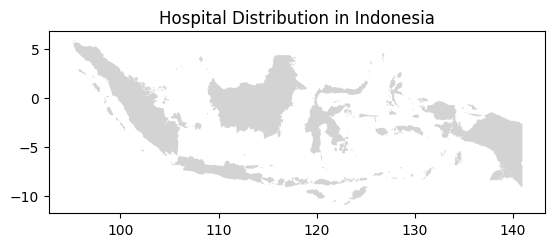

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

indonesia.plot(color="lightgrey")

plt.title("Hospital Distribution in Indonesia")

plt.show()

In [72]:
health_dist = (
    df.groupby("propinsi")
    .agg(
        jumlah_rumah_sakit=("id", "count"),
        total_tempat_tidur=("total_tempat_tidur", "sum"),
        total_tenaga_kerja=("total_tenaga_kerja", "sum"),
        total_layanan=("total_layanan", "sum")
    )
    .reset_index()
)

health_dist.head()

,propinsi,jumlah_rumah_sakit,total_tempat_tidur,total_tenaga_kerja,total_layanan
0,ACEH,79,11030,24643,2833
1,BALI,79,9203,22833,3998
2,BANTEN,129,15846,29083,5892
3,BENGKULU,26,2735,6997,852
4,DKI JAKARTA,188,30357,82785,10859


In [75]:
from sklearn.preprocessing import MinMaxScaler

score_df = health_dist.copy()

scaler = MinMaxScaler()

score_df[["rs_scaled", "bed_scaled", "workforce_scaled", "services_scaled"]] = scaler.fit_transform(
    score_df[["jumlah_rumah_sakit", "total_tempat_tidur", "total_tenaga_kerja", "total_layanan"]]
)

score_df["healthcare_access_index"] = (
    score_df["rs_scaled"] * 0.25 +
    score_df["bed_scaled"] * 0.25 +
    score_df["workforce_scaled"] * 0.25 +
    score_df["services_scaled"] * 0.25
)

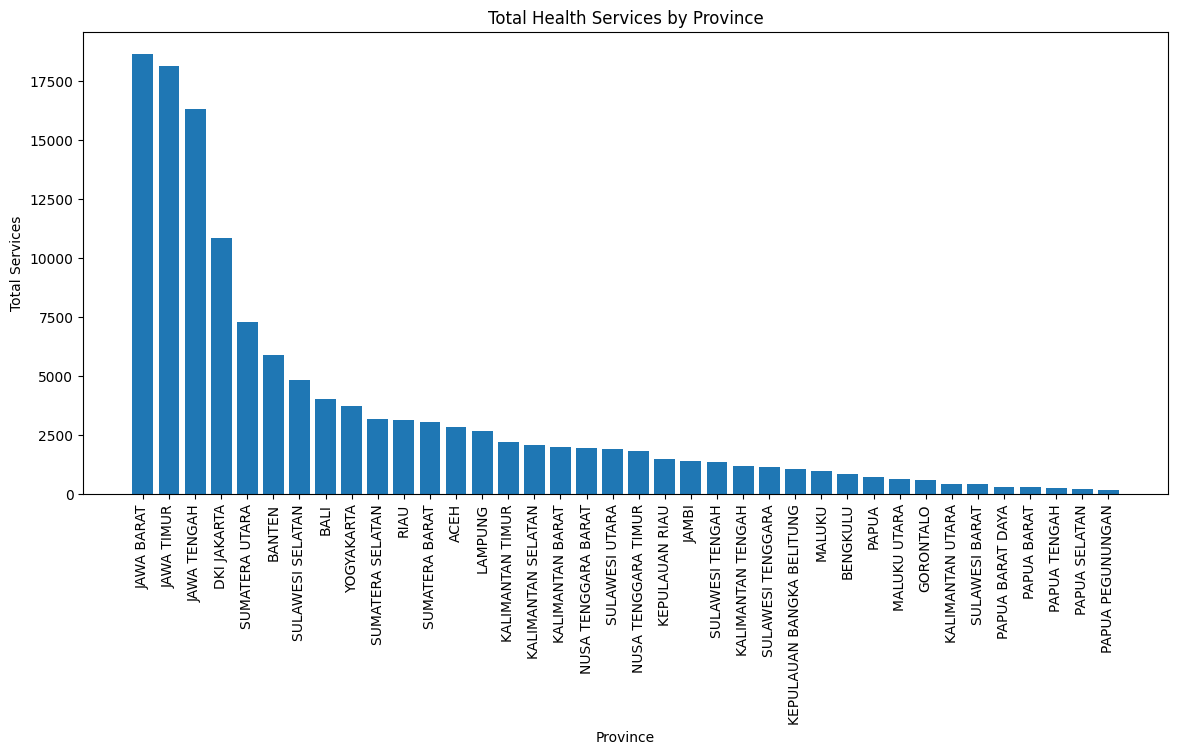

In [79]:
plot_df = health_dist.sort_values("total_layanan", ascending=False)

plt.figure(figsize=(14,6))
plt.bar(plot_df["propinsi"], plot_df["total_layanan"])
plt.xticks(rotation=90)
plt.title("Total Health Services by Province")
plt.xlabel("Province")
plt.ylabel("Total Services")
plt.show()

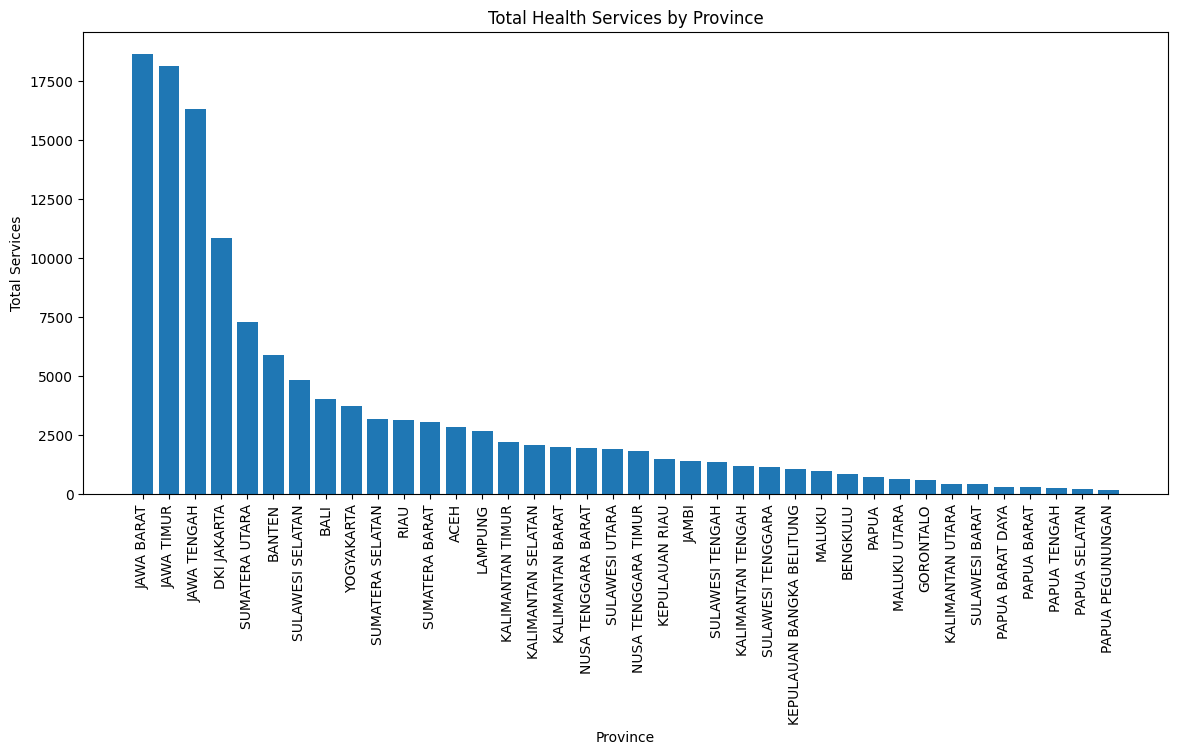

In [80]:
plot_df = health_dist.sort_values("total_layanan", ascending=False)

plt.figure(figsize=(14,6))
plt.bar(plot_df["propinsi"], plot_df["total_layanan"])
plt.xticks(rotation=90)
plt.title("Total Health Services by Province")
plt.xlabel("Province")
plt.ylabel("Total Services")
plt.show()

In [81]:
score_df = health_dist.copy()

scaler = MinMaxScaler()

score_df[["rs_scaled", "bed_scaled", "workforce_scaled", "services_scaled"]] = scaler.fit_transform(
    score_df[["jumlah_rumah_sakit", "total_tempat_tidur", "total_tenaga_kerja", "total_layanan"]]
)

score_df["healthcare_access_index"] = (
    score_df["rs_scaled"] * 0.25 +
    score_df["bed_scaled"] * 0.25 +
    score_df["workforce_scaled"] * 0.25 +
    score_df["services_scaled"] * 0.25
)

score_df.sort_values("healthcare_access_index", ascending=False).head(10)

,propinsi,jumlah_rumah_sakit,total_tempat_tidur,total_tenaga_kerja,total_layanan,rs_scaled,bed_scaled,workforce_scaled,services_scaled,healthcare_access_index
7,JAWA BARAT,421,59802,113887,18649,0.974118,0.767958,0.977652,1.000000,0.929932
9,JAWA TIMUR,432,52252,116483,18109,1.000000,0.670364,1.000000,0.970784,0.910287
8,JAWA TENGAH,355,77753,102862,16296,0.818824,1.000000,0.882740,0.872694,0.893564
4,DKI JAKARTA,188,30357,82785,10859,0.425882,0.387340,0.709903,0.578532,0.525414
36,SUMATERA UTARA,202,23813,38964,7281,0.458824,0.302749,0.332659,0.384948,0.369795
2,BANTEN,129,15846,29083,5892,0.287059,0.199765,0.247596,0.309798,0.261054
30,SULAWESI SELATAN,123,16710,31709,4802,0.272941,0.210933,0.270203,0.250825,0.251225
1,BALI,79,9203,22833,3998,0.169412,0.113895,0.193791,0.207326,0.171106
35,SUMATERA SELATAN,87,10366,23931,3151,0.188235,0.128928,0.203244,0.161500,0.170477
0,ACEH,79,11030,24643,2833,0.169412,0.137511,0.209373,0.144295,0.165148


In [95]:
import geopandas as gpd

geojson_url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province-simple.json"

gdf = gpd.read_file(geojson_url)

gdf.head()

,ID,kode,Propinsi,SUMBER,geometry
0,1,85,IRIAN JAYA TIMUR,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,"MULTIPOLYGON (((137.91666 -1.49852, 137.9338 -..."
1,2,52,NUSATENGGARA BARAT,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,"MULTIPOLYGON (((117.6272 -8.5064, 117.6347 -8...."
2,3,75,GORONTALO,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,"POLYGON ((122.18814 1.0453, 122.22627 1.00335,..."
3,4,74,SULAWESI TENGGARA,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,"MULTIPOLYGON (((120.98423 -2.83534, 121.07834 ..."
4,5,34,DAERAH ISTIMEWA YOGYAKARTA,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,"POLYGON ((110.01183 -7.8869, 110.04295 -7.8920..."


In [97]:
gdf["Propinsi"] = gdf["Propinsi"].astype(str).str.strip().str.upper()
score_df["propinsi"] = score_df["propinsi"].astype(str).str.strip().str.upper()

In [98]:
gdf.columns

Index(['ID', 'kode', 'Propinsi', 'SUMBER', 'geometry'], dtype='object')

In [99]:
gdf["Propinsi"] = gdf["Propinsi"].astype(str).str.strip().str.upper()
score_df["propinsi"] = score_df["propinsi"].astype(str).str.strip().str.upper()

map_df = gdf.merge(
    score_df[[
        "propinsi",
        "jumlah_rumah_sakit",
        "total_tempat_tidur",
        "total_tenaga_kerja",
        "total_layanan",
        "healthcare_access_index"
    ]],
    left_on="Propinsi",
    right_on="propinsi",
    how="left"
)

In [100]:
gdf["Propinsi"] = gdf["Propinsi"].astype(str).str.strip().str.upper()
score_df["propinsi"] = score_df["propinsi"].astype(str).str.strip().str.upper()

map_df = gdf.merge(
    score_df[[
        "propinsi",
        "jumlah_rumah_sakit",
        "total_tempat_tidur",
        "total_tenaga_kerja",
        "total_layanan",
        "healthcare_access_index"
    ]],
    left_on="Propinsi",
    right_on="propinsi",
    how="left"
)

In [101]:
sorted(set(score_df["propinsi"]) - set(gdf["Propinsi"]))

['ACEH',
 'BANTEN',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'NUSA TENGGARA BARAT',
 'PAPUA',
 'PAPUA BARAT',
 'PAPUA BARAT DAYA',
 'PAPUA PEGUNUNGAN',
 'PAPUA SELATAN',
 'PAPUA TENGAH',
 'SULAWESI BARAT',
 'YOGYAKARTA']

In [103]:
map_df.fillna(0, inplace=True)

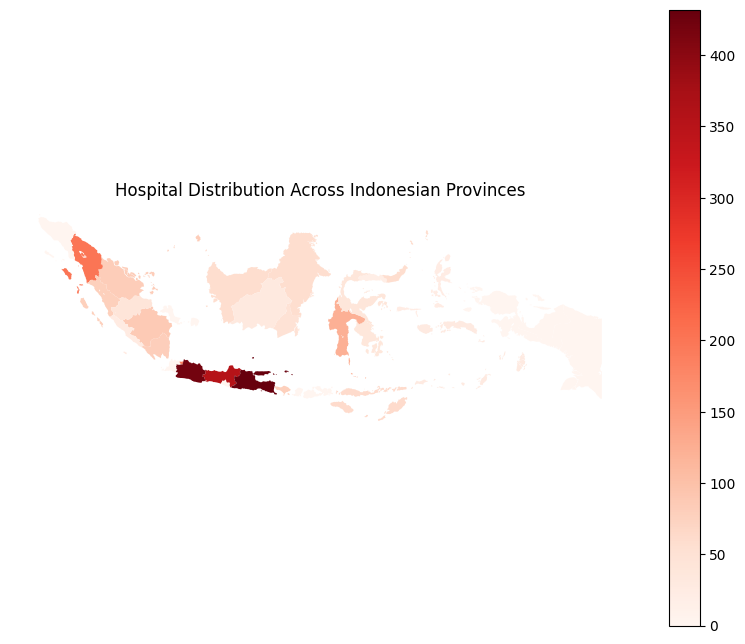

In [104]:
import matplotlib.pyplot as plt

map_df.plot(
    column="jumlah_rumah_sakit",
    cmap="Reds",
    legend=True,
    figsize=(10,8)
)

plt.title("Hospital Distribution Across Indonesian Provinces")
plt.axis("off")
plt.show()

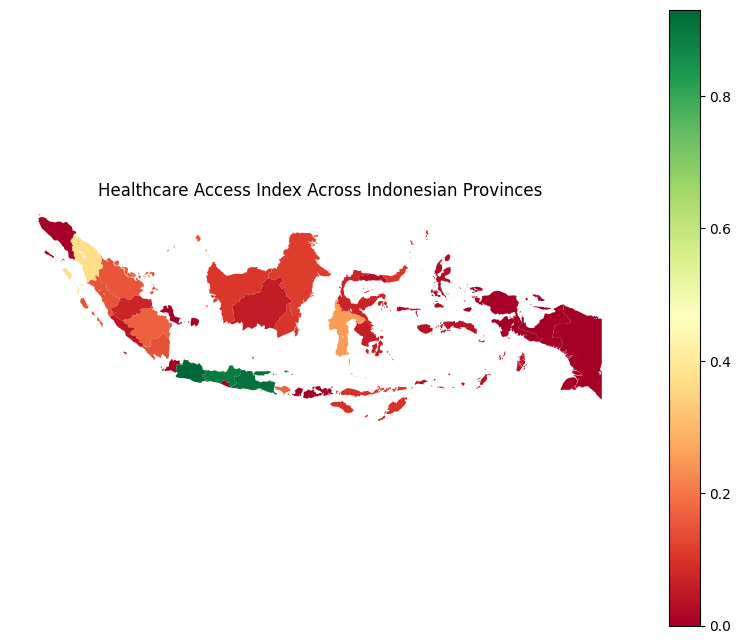

In [105]:
map_df.plot(
    column="healthcare_access_index",
    cmap="RdYlGn",
    legend=True,
    figsize=(10,8)
)

plt.title("Healthcare Access Index Across Indonesian Provinces")
plt.axis("off")
plt.show()

In [106]:
import folium

m = folium.Map(location=[-2.5,118], zoom_start=5, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=map_df.to_json(),
    data=map_df,
    columns=["Propinsi","healthcare_access_index"],
    key_on="feature.properties.Propinsi",
    fill_color="RdYlGn",
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name="Healthcare Access Index"
).add_to(m)

m

## Healthcare Service Distribution Analysis

The visualization shows that healthcare services in Indonesia are not evenly distributed across provinces. Provinces located in Java such as West Java, East Java, and DKI Jakarta have significantly higher numbers of health services compared to other regions.

This pattern indicates that healthcare infrastructure is still concentrated in economically developed areas. Meanwhile, several provinces in eastern Indonesia show relatively lower availability of healthcare services.

This inequality highlights the importance of improving healthcare accessibility in underserved regions to ensure more balanced health service distribution across the country.

## Insight: Total Health Services by Province

The bar chart shows the distribution of healthcare services across Indonesian provinces. Provinces such as West Java, East Java, and Central Java have the highest number of healthcare services.

This indicates that healthcare infrastructure tends to concentrate in densely populated regions. Meanwhile, provinces in eastern Indonesia show significantly lower numbers of health services, which may suggest limited healthcare accessibility.

These findings emphasize the importance of strengthening healthcare infrastructure in regions with lower service availability.

## Spatial Distribution of Healthcare Access

The spatial visualization highlights disparities in healthcare accessibility across Indonesia. Provinces with higher healthcare access index values tend to have more hospitals, greater bed capacity, and larger healthcare workforce.

On the other hand, provinces with lower index values may face challenges in accessing healthcare services. This suggests the need for strategic policy interventions to improve healthcare infrastructure and service availability in underserved areas.